In [1]:
import snapatac2 as snap
import scanpy as sc
import re
import pandas as pd
import matplotlib.pyplot as plt

/home/armstrong/miniconda3/envs/scvi/lib/python3.9/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.15) or chardet (5.2.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


In [2]:
def str_extract(data, pattern):
    import re
    import pandas as pd
    """
    Extracts a part of the string based on a regex pattern.
    :param data: A list or pandas Series containing string elements.
    :param pattern: A regex pattern to search for in each string element.
    :return: A list or pandas Series (depending on the input) of the extracted substrings.
    """
    # Define a helper function to apply regex on each element
    def extract(string):
        match = re.search(pattern, string)
        # Return the matched group if a match is found; otherwise, return None
        return match.group(0) if match else None
    # Apply the helper function to each element in the input
    if isinstance(data, list):
        # If the input is a list, use list comprehension
        return [extract(item) for item in data]
    elif isinstance(data, pd.Series):
        # If the input is a pandas Series, use the .apply() method
        return data.apply(extract).to_list()
    else:
        raise ValueError("Input must be a list or pandas.core.series.Series")

# HPAP

## QC

In [39]:
hpap_scATAC_fragment = '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/HPAP_out/fragments.tsv.gz'

In [40]:
hpap_scATAC = snap.pp.import_fragments(
    hpap_scATAC_fragment,
    file= 'scATAC_h5ad/islet_scATAC_HPAP.h5ad',
    chrom_sizes=snap.genome.hg38,
    min_num_fragments=1000,
    sorted_by_barcode = False
)

In [41]:
snap.metrics.tsse(hpap_scATAC, snap.genome.hg38)

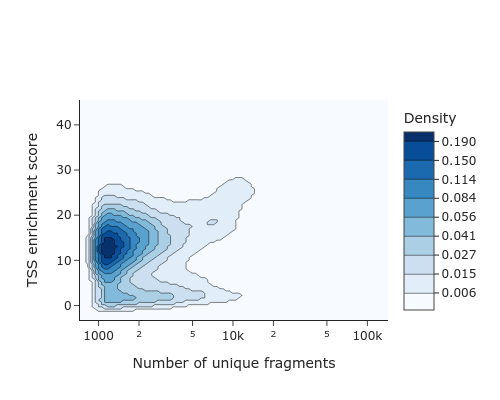

In [42]:
snap.pl.tsse(hpap_scATAC, interactive=False)

In [ ]:
snap.pp.filter_cells(hpap_scATAC, min_counts=500, min_tsse=5, max_counts=5000)
snap.pp.add_tile_matrix(hpap_scATAC,bin_size = 5000)

In [44]:
snap.pp.select_features(hpap_scATAC, n_features=50000)
snap.pp.scrublet(hpap_scATAC)
snap.pp.filter_doublets(hpap_scATAC)

2026-03-18 16:15:15 - INFO - Selected 50000 features.
2026-03-18 16:15:22 - INFO - Simulating doublets...
2026-03-18 16:15:23 - INFO - Spectral embedding ...
2026-03-18 16:17:46 - INFO - Calculating doublet scores...
2026-03-18 16:18:13 - INFO - Detected doublet rate = 1.546%


In [45]:
snap.tl.spectral(hpap_scATAC)
snap.tl.umap(hpap_scATAC)

In [46]:
snap.pp.knn(hpap_scATAC)
snap.tl.leiden(hpap_scATAC)

In [47]:
hpap_scATAC.close()

## Demendional reduction

In [4]:
hpap_scATAC = sc.read_h5ad('scATAC_h5ad/islet_scATAC_HPAP.h5ad')

In [5]:
numbers = []
for barcode in hpap_scATAC.obs_names:
    match = re.search(r'\d+', barcode)
    if match:
        number = int(match.group())
        numbers.append(number)
    else:
        numbers.append(None)
hpap_scATAC.obs['number'] = numbers

In [6]:
hpap_library = pd.read_csv('/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/HPAP_out/cellrangera_hpap_atac_aggr_libraries.csv')
hpap_library['number'] = [i + 1 for i in hpap_library.index.to_list()]
hpap_library['donor'] = str_extract(hpap_library['library_id'].to_list(),'HPAP-\d+')
merged_data = pd.merge(pd.DataFrame(hpap_scATAC.obs['number'],columns = ['number']), hpap_library, left_on='number', right_on='number', how='left')


In [7]:
hpap_scATAC.obs['library_id'] = merged_data['library_id'].to_list()
hpap_scATAC.obs['donor'] = merged_data['donor'].to_list()
hpap_scATAC.obs['project'] = 'HPAP'

In [9]:
snap.pp.select_features(hpap_scATAC, n_features=200000)
snap.tl.spectral(hpap_scATAC)
snap.tl.umap(hpap_scATAC,n_neighbors=50, min_dist=0.3)
snap.pp.knn(hpap_scATAC)
snap.tl.leiden(hpap_scATAC,resolution=4)

2026-04-05 00:20:55 - INFO - Selected 200000 features.
/home/armstrong/miniconda3/envs/scvi/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/armstrong/miniconda3/envs/scvi/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/armstro

In [12]:
snap.tl.leiden(hpap_scATAC,resolution=1)

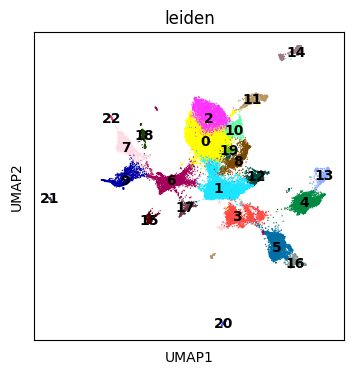

In [15]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(hpap_scATAC,color = 'leiden',legend_loc = 'on data')

In [14]:
hpap_scATAC.obs['leiden'].value_counts()

leiden
0     7524
1     4333
2     3589
3     2210
4     2184
5     2147
6     1972
7     1714
8     1437
9     1209
10    1014
11     735
12     723
13     630
14     565
15     508
16     453
17     349
18     312
19     208
20     195
21     116
22      81
Name: count, dtype: int64

In [16]:
hpap_scATAC = hpap_scATAC[~hpap_scATAC.obs['leiden'].isin(['20','21','22'])]


In [22]:
from utils.utils import *
hpap_scATAC = run_lsi(
    hpap_scATAC,
    n_components=30,
    n_features=200000,
    use_snap_feature=True,
    binarize=False
)

2026-04-05 00:34:13 - INFO - Selected 300000 features.


In [24]:
snap.tl.umap(hpap_scATAC,n_neighbors=30,min_dist=0.1)
snap.tl.leiden(hpap_scATAC,resolution=1)

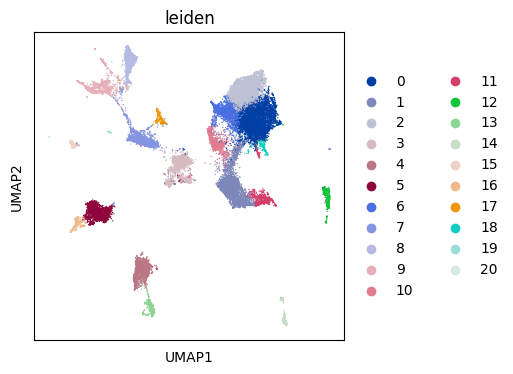

In [30]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(hpap_scATAC,color = 'leiden')

In [28]:
hpap_scATAC.write_h5ad('scATAC_h5ad/islet_scATAC_HPAP_raw_annotated.h5ad')

## Cell type annotation

In [3]:
hpap_scATAC = sc.read_h5ad('scATAC_h5ad/islet_scATAC_HPAP_raw_annotated.h5ad')

In [10]:
gene_matrix = snap.pp.make_gene_matrix(hpap_scATAC,'protein_coding_genes.gff3')

In [11]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [12]:
gene_matrix.layers['counts'] = gene_matrix.X.copy()
gene_matrix.obs['batch'] = gene_matrix.obs['donor']
gene_matrix.obs["leiden"] = hpap_scATAC.obs["leiden"]
gene_matrix.obsm["X_umap"] = hpap_scATAC.obsm["X_umap"]

In [29]:
sc.tl.rank_genes_groups(gene_matrix, 'leiden',  method='t-test',use_raw=False,key_added='leiden_ttest')
leiden_top5_genes = {
    leiden: gene_matrix.uns['leiden_ttest']['names'][leiden][:20].tolist()
    for leiden in gene_matrix.uns['leiden_ttest']['names'].dtype.names
}

/home/armstrong/miniconda3/envs/scvi/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/armstrong/miniconda3/envs/scvi/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/armstrong/miniconda3/envs/scvi/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:440: Perf

In [ ]:
adata_scRNA = sc.read_h5ad('h5ad/human_islet_sample12.h5ad')
adata_scRNA.X.max()

In [15]:
adata_scRNA

AnnData object with n_obs × n_vars = 65006 × 15282
    obs: 'orig.ident', 'sample', 'batch', 'n_genes', 'n_counts', 'percent.mt', 'cell_type', 'author', 'BMI', 'HbA1c', 'disease'
    var: 'name'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'author_colors', 'cell_type_colors', 'donor_colors', 'hvg', 'leiden', 'leiden_1_colors', 'neighbors'
    obsm: 'X_scANVI', 'X_scANVI_mde', 'X_scVI', 'X_scVI_mde'
    obsp: 'connectivities', 'distances'

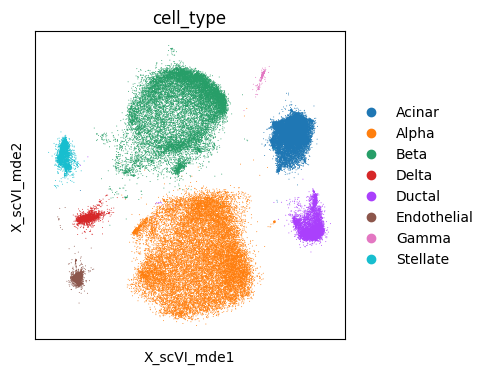

In [17]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.embedding(adata_scRNA,basis='X_scVI_mde',color = 'cell_type')

In [18]:
sc.pp.normalize_total(adata_scRNA, target_sum=1e4)
sc.pp.log1p(adata_scRNA)
sc.tl.rank_genes_groups(adata_scRNA, 'cell_type',  method='t-test',use_raw=False,key_added='ct_ttest')


In [19]:
def intersect(list1,list2):
    set1 = set(list1)
    set2 = set(list2)
    intersected_set = set1.intersection(set2) 
    return(list(intersected_set))
ct_top5_genes = {
    leiden: intersect(adata_scRNA.uns['ct_ttest']['names'][leiden][:5].tolist(),gene_matrix.var_names.to_list())
    for leiden in adata_scRNA.uns['ct_ttest']['names'].dtype.names
}

In [30]:
ct_top5_genes

{'Acinar': ['SPINK1', 'CPA2', 'CELA3A', 'PRSS1', 'REG1A'],
 'Alpha': ['TTR', 'GC', 'CLU', 'GCG', 'CHGA'],
 'Beta': ['INS', 'ADCYAP1', 'PCSK1', 'SCG3', 'UCHL1'],
 'Delta': ['SEC11C', 'PCSK1N', 'SST', 'RBP4', 'SCG5'],
 'Ductal': ['S100A10', 'TACSTD2', 'KRT8', 'S100A11', 'ANXA2'],
 'Endothelial': ['CCDC85B', 'PTMA', 'ESAM', 'B2M', 'GNG11'],
 'Gamma': ['PCSK1N', 'PPY', 'FXYD2', 'SCG5', 'CHGB'],
 'Stellate': ['LGALS1', 'COL6A2', 'DCN', 'RPLP1', 'IGFBP7']}

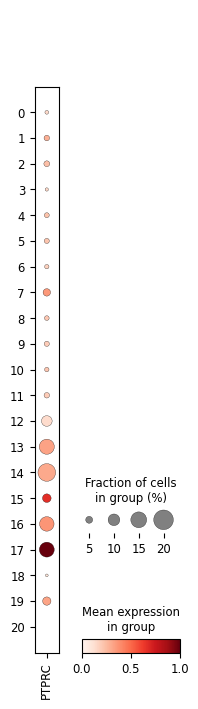

In [27]:
sc.pl.dotplot(
    gene_matrix,['PTPRC'],
    standard_scale='var',
    groupby='leiden')

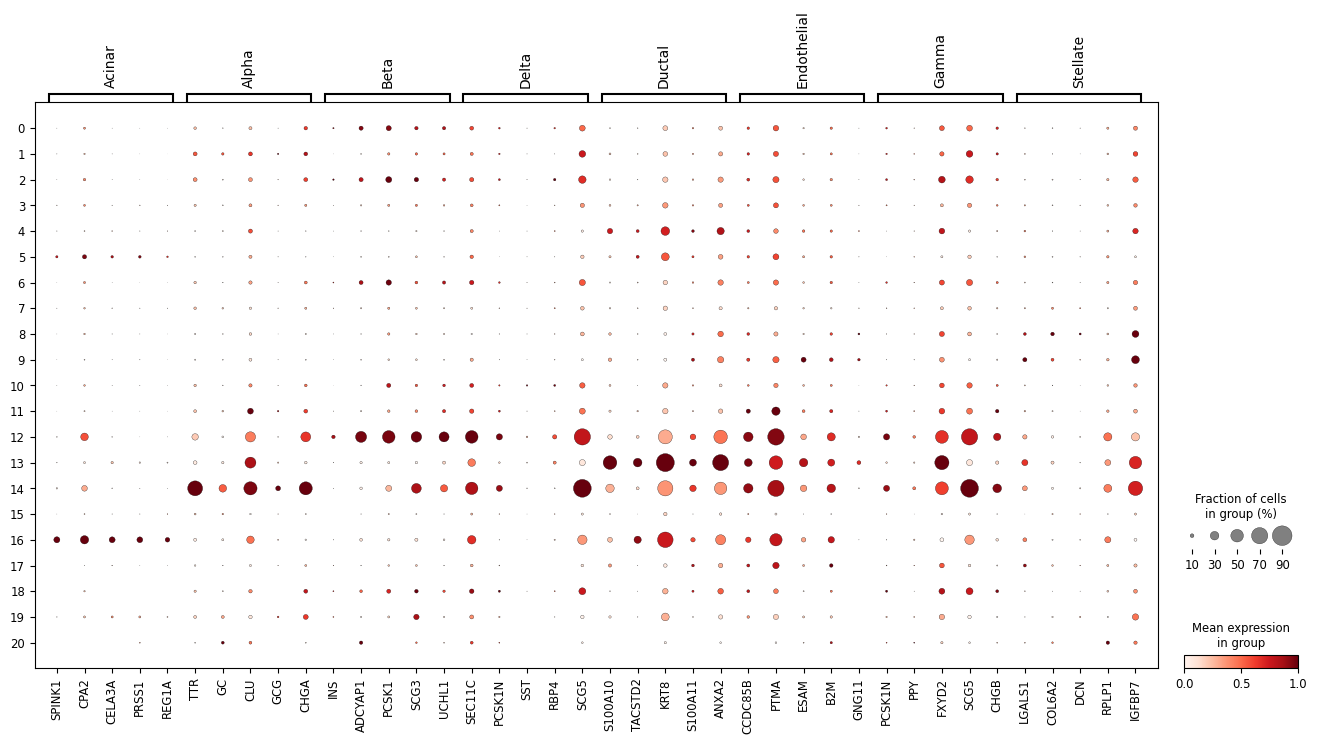

In [21]:
sc.pl.dotplot(
    gene_matrix, ct_top5_genes ,
    standard_scale='var',
    groupby='leiden')

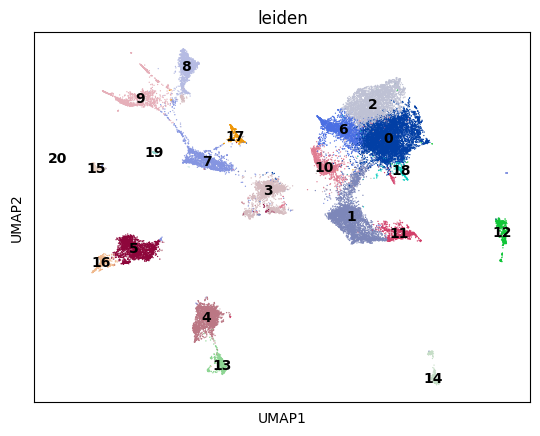

In [22]:
sc.pl.umap(hpap_scATAC,color = 'leiden',legend_loc = 'on data')

In [40]:
leiden_ct = {'Acinar': [5,16],
 'Alpha': [1,11],
 'Beta': [0,2,6,18],
 'Delta': [12],
 'Ductal': [4,13],
 'Endothelial': [9],
 'Gamma': [14],
 'Stellate': [8],
 'Immune': [17],
 'Low qulaity': [3,7,10,15,19,20]}

In [41]:
cluster2celltype = {
    str(cluster): str(ct)
    for ct, clusters in leiden_ct.items()
    for cluster in clusters
}
hpap_scATAC.obs['cell_type'] = [cluster2celltype[i] for i in hpap_scATAC.obs['leiden']]
gene_matrix.obs['cell_type'] = (
    gene_matrix.obs['leiden']
    .map(cluster2celltype)
    .astype('category')
)

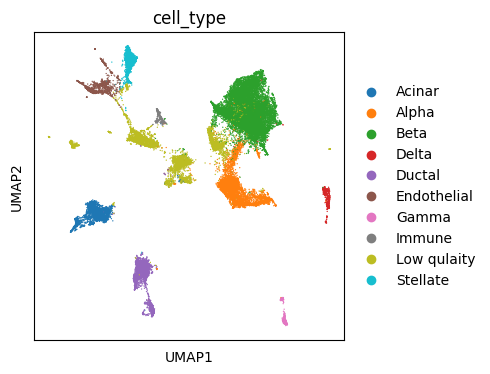

In [43]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(hpap_scATAC,color = 'cell_type')

In [44]:
hpap_scATAC.write_h5ad('scATAC_h5ad/islet_scATAC_HPAP_raw_annotated.h5ad')

## Final embeding

In [47]:
hpap_scATAC_sub = hpap_scATAC[hpap_scATAC.obs['cell_type'] != 'Low qulaity'].copy()

In [51]:
from utils.utils import *
hpap_scATAC_sub = run_lsi(
    hpap_scATAC_sub,
    n_components=30,
    n_features=200000,
    use_snap_feature=True,
    binarize=False
)

2026-04-09 16:52:02 - INFO - Selected 200000 features.


In [53]:
snap.tl.umap(hpap_scATAC_sub,n_neighbors=30,min_dist=0.1)
snap.tl.leiden(hpap_scATAC_sub,resolution=1)

In [57]:
snap.tl.leiden(hpap_scATAC_sub,resolution=2)

In [61]:
hpap_scATAC_sub = hpap_scATAC_sub[hpap_scATAC_sub.obs['leiden'] != '13'].copy()

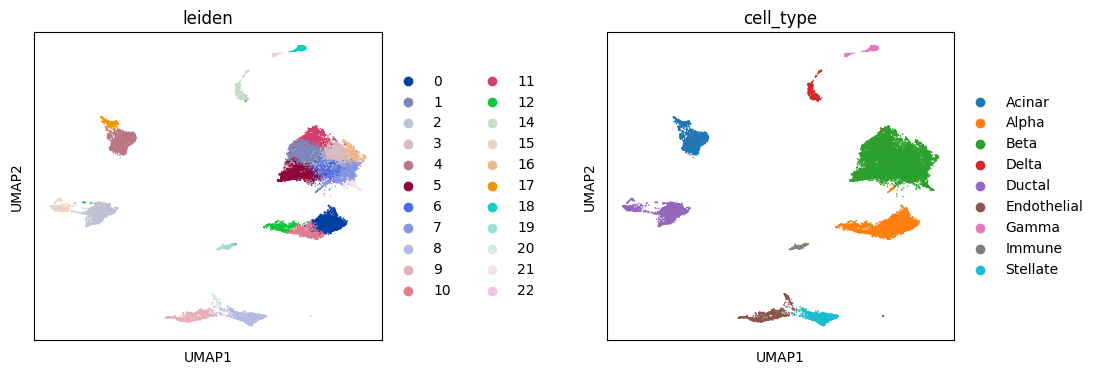

In [62]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(hpap_scATAC_sub,color = ['leiden','cell_type'],wspace = 0.5)

In [63]:
hpap_scATAC_sub.write_h5ad('scATAC_h5ad/islet_scATAC_HPAP_final_annotated.h5ad')

In [ ]:
donor_counts = hpap_scATAC_sub.obs['donor'].value_counts()
keep_donors = donor_counts[donor_counts > 200].index
hpap_scATAC_keep= hpap_scATAC_sub[hpap_scATAC_sub.obs['donor'].isin(keep_donors)].copy()

In [ ]:
snap.ex.export_fragments(hpap_scATAC_keep,groupby='donor', suffix='.tsv.gz',out_dir = '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/fragment_high_quality_donor/')

In [71]:
hpap_scATAC_keep.obs.to_csv('/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/fragment_high_quality_donor/obs.csv')

# NG data

In [3]:
NG_scATAC_fragment = '/data/armstrong/islet_public_dataset/islet_biobank_multiome_downsteam/scATAC-seq/fragment_file_scATAC/fragment/fragments.tsv.gz'
NG_scATAC = snap.pp.import_fragments(
    NG_scATAC_fragment,
    file= 'scATAC_h5ad/islet_scATAC_NG.h5ad',
    chrom_sizes=snap.genome.hg38,
    min_num_fragments=1000,
    n_jobs=40,
    sorted_by_barcode = False
)

In [4]:
snap.metrics.tsse(NG_scATAC, snap.genome.hg38)

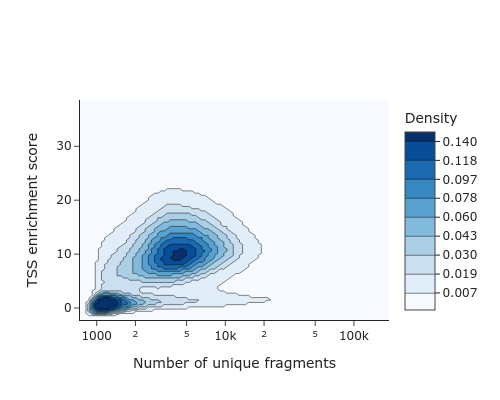

In [5]:
snap.pl.tsse(NG_scATAC, interactive=False)

In [6]:
snap.pp.filter_cells(NG_scATAC, min_counts=500, min_tsse=7, max_counts=50000)
snap.pp.add_tile_matrix(NG_scATAC,bin_size = 5000)

In [7]:
NG_scATAC.close()

## Demendional reduction

## QC

In [8]:
NG_scATAC = sc.read_h5ad('scATAC_h5ad/islet_scATAC_NG.h5ad')

In [37]:
library_info = pd.read_csv('/data/armstrong/islet_public_dataset/islet_biobank_multiome_downsteam/scATAC-seq/fragment_file_scATAC/fragment/cellrangera_atac_aggr_libraries.csv')
lib_dict = dict(zip(library_info.index + 1, library_info.library_id))
NG_scATAC.obs['donor_idx'] = [int(i)  for i in str_extract(NG_scATAC.obs_names.to_list(),'(?<=-)\d+')]
NG_scATAC.obs['donor'] = NG_scATAC.obs['donor_idx'].map(lib_dict)

In [39]:
NG_scATAC.obs['donor'].value_counts()

donor
SAMP-1697    14859
SAMP-1611     9914
SAMP-1610     8190
SAMP-1149     8142
SAMP-1137     7237
SAMP-1151     6986
SAMP-1602     6396
SAMP-1607     6176
SAMP-692      5915
SAMP-1136     5504
SAMP-1097     5501
SAMP-1148     5011
SAMP-1144     4953
SAMP-689      4539
Name: count, dtype: int64

In [11]:
from utils.utils import *
NG_scATAC = run_lsi(
    NG_scATAC,
    n_components=30,
    n_features=100000,
    use_snap_feature=True,
    binarize=False
)

2026-05-21 11:44:17 - INFO - Selected 100000 features.


In [18]:
snap.tl.umap(NG_scATAC,use_rep='X_lsi',n_neighbors=50, min_dist=0.3)

... storing 'donor' as categorical


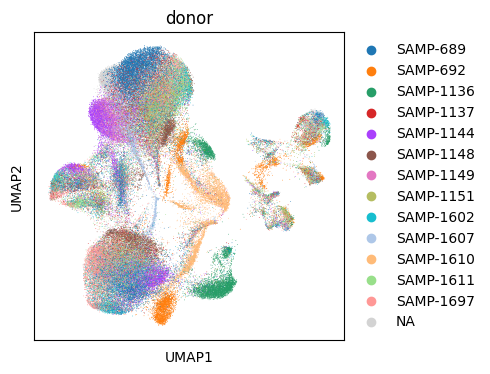

In [19]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(NG_scATAC,color = ['donor'])

In [42]:
sc.external.pp.harmony_integrate(NG_scATAC, 'donor',basis = 'X_lsi')
sc.pp.neighbors(NG_scATAC, use_rep='X_pca_harmony')

2026-05-21 13:36:58,083 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 13:36:58 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 13:37:04,978 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-21 13:37:04 - INFO - sklearn.KMeans initialization complete.
2026-05-21 13:37:05,538 - harmonypy - INFO - Iteration 1 of 10
2026-05-21 13:37:05 - INFO - Iteration 1 of 10
2026-05-21 13:37:53,041 - harmonypy - INFO - Iteration 2 of 10
2026-05-21 13:37:53 - INFO - Iteration 2 of 10
2026-05-21 13:38:37,688 - harmonypy - INFO - Iteration 3 of 10
2026-05-21 13:38:37 - INFO - Iteration 3 of 10
2026-05-21 13:39:21,952 - harmonypy - INFO - Iteration 4 of 10
2026-05-21 13:39:21 - INFO - Iteration 4 of 10
2026-05-21 13:40:05,491 - harmonypy - INFO - Iteration 5 of 10
2026-05-21 13:40:05 - INFO - Iteration 5 of 10
2026-05-21 13:40:49,169 - harmonypy - INFO - Iteration 6 of 10
2026-05-21 13:40:49 - INFO - Iteration 6 of 10
2026-05-21

In [43]:
sc.tl.umap(NG_scATAC,min_dist=0.3)
sc.tl.leiden(NG_scATAC,resolution=1)

/tmp/ipykernel_2784512/2055479117.py:2: FutureWarning:

In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.



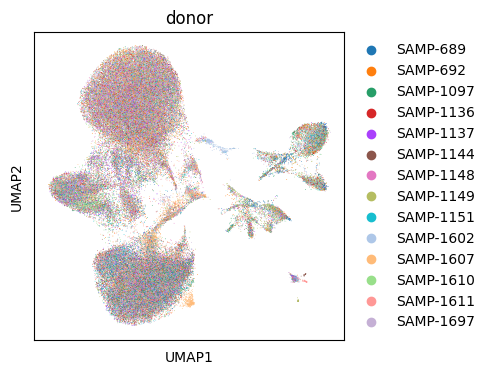

In [45]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(NG_scATAC,color = ['donor'])

... storing 'donor' as categorical


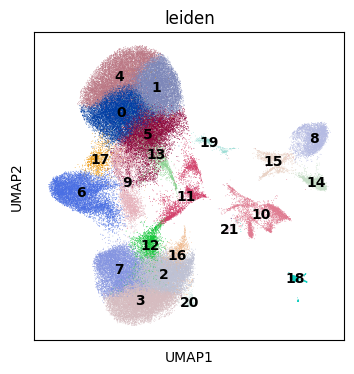

In [44]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(NG_scATAC,color = ['leiden'],legend_loc = 'on data')

In [46]:
NG_scATAC.write_h5ad('scATAC_h5ad/islet_scATAC_NG_raw_annotated.h5ad')

## CT annotation

In [47]:
gene_matrix = snap.pp.make_gene_matrix(NG_scATAC,'protein_coding_genes.gff3')

In [48]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)

In [49]:
gene_matrix.layers['counts'] = gene_matrix.X.copy()
gene_matrix.obs['batch'] = gene_matrix.obs['donor']
gene_matrix.obs["leiden"] = NG_scATAC.obs["leiden"]
gene_matrix.obsm["X_umap"] = NG_scATAC.obsm["X_umap"]

In [ ]:
sc.tl.rank_genes_groups(gene_matrix, 'leiden',  method='t-test',use_raw=False,key_added='leiden_ttest')
leiden_top5_genes = {
    leiden: gene_matrix.uns['leiden_ttest']['names'][leiden][:20].tolist()
    for leiden in gene_matrix.uns['leiden_ttest']['names'].dtype.names
}

In [51]:
adata_scRNA = sc.read_h5ad('h5ad/human_islet_sample12.h5ad')
adata_scRNA.X.max()

158798.0

In [52]:
sc.pp.normalize_total(adata_scRNA, target_sum=1e4)
sc.pp.log1p(adata_scRNA)
sc.tl.rank_genes_groups(adata_scRNA, 'cell_type',  method='t-test',use_raw=False,key_added='ct_ttest')


In [53]:
def intersect(list1,list2):
    set1 = set(list1)
    set2 = set(list2)
    intersected_set = set1.intersection(set2) 
    return(list(intersected_set))
ct_top5_genes = {
    leiden: intersect(adata_scRNA.uns['ct_ttest']['names'][leiden][:5].tolist(),gene_matrix.var_names.to_list())
    for leiden in adata_scRNA.uns['ct_ttest']['names'].dtype.names
}

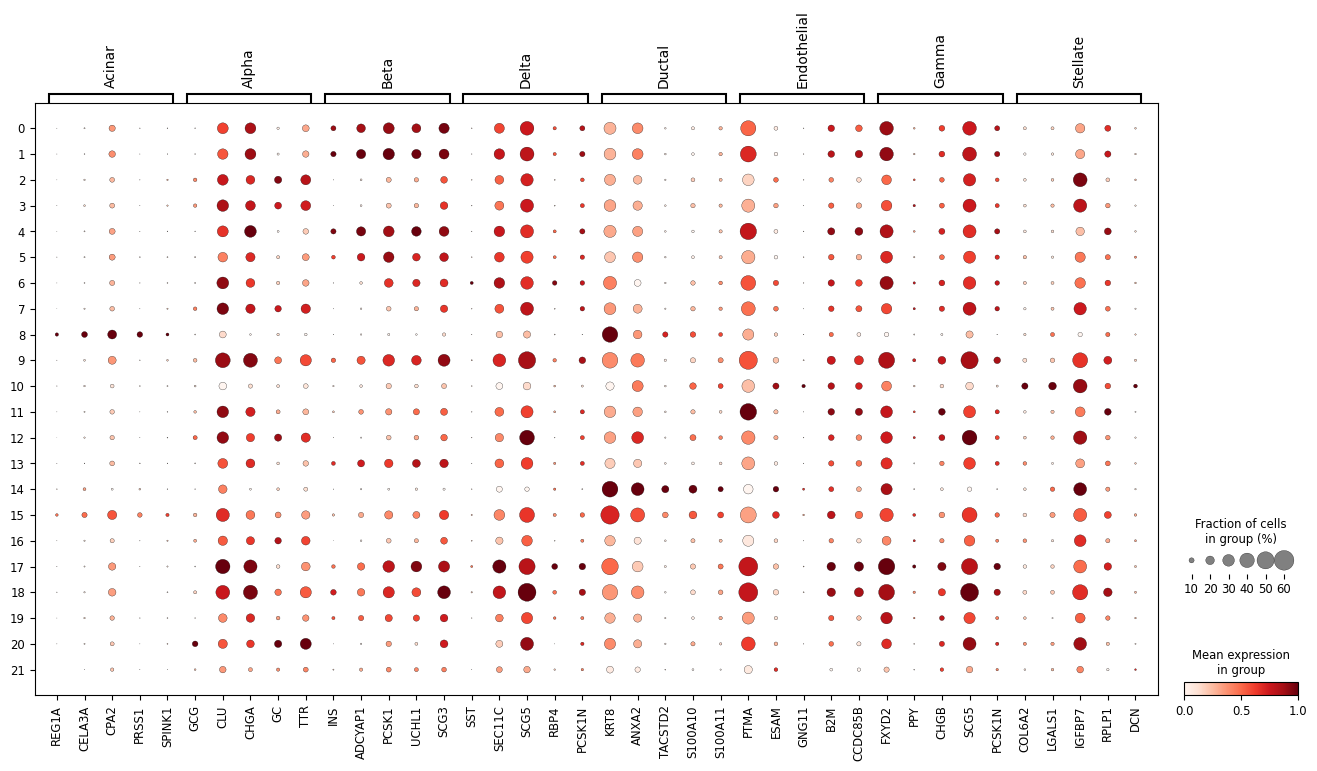

In [54]:
sc.pl.dotplot(
    gene_matrix, ct_top5_genes ,
    standard_scale='var',
    groupby='leiden')

In [58]:
pancreas_markers = {
    "Alpha": ["GCG", "TTR", "ARX"],
    "Beta": ["INS", "IAPP", "MAFA"],
    "Delta": ["SST", "HHEX", "RBP4"],
    "Gamma_PP": ["PPY", "PAX6", "ISL1"],
    "Ductal": ["CFTR", "KRT19", "MUC1"],
    "Acinar": ["PRSS1", "REG1A", "CPA1"],
    "Endothelial": ["PECAM1", "KDR", "VWF"],
    "Stellate": ["COL1A1", "DCN", "COL3A1"],
    "Mast":["CPA3", "TPSAB1", "TPSB2"],
    'Pericyte':['RGS5'],
    "Myeloid": ["PTPRC", "CD68", "CSF1R"]
}

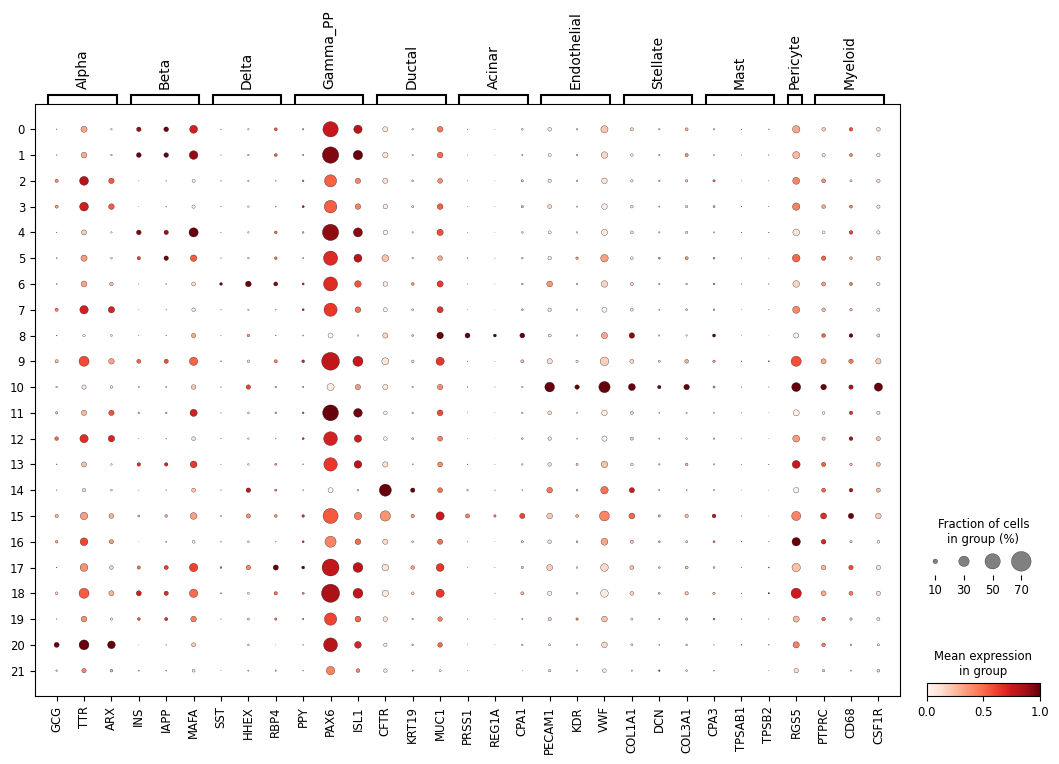

In [59]:
sc.pl.dotplot(
    gene_matrix, pancreas_markers ,
    standard_scale='var',
    groupby='leiden')

In [68]:
leiden_ct = {'Acinar': [8,15],
 'Alpha': [2,3,7,12,16],
 'Beta': [0,1,4,5],
 'Delta': [6],
 'Ductal': [14],
 'Endothelial': [10],
 'Gamma': [17],
 'Stellate': [21],
 'Immune': [18],
 'Low qulaity': [9,11,13,19,20]}

In [69]:
cluster2celltype = {
    str(cluster): str(ct)
    for ct, clusters in leiden_ct.items()
    for cluster in clusters
}
NG_scATAC.obs['cell_type'] = [cluster2celltype[i] for i in NG_scATAC.obs['leiden']]
gene_matrix.obs['cell_type'] = (
    gene_matrix.obs['leiden']
    .map(cluster2celltype)
    .astype('category')
)

... storing 'cell_type' as categorical


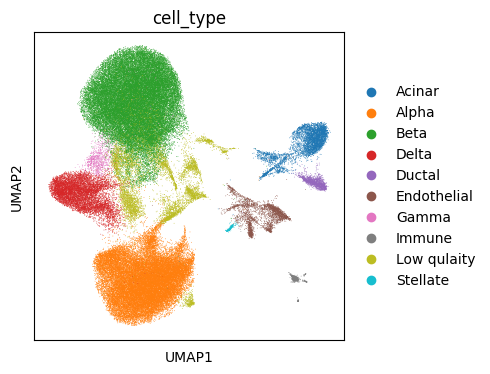

In [70]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(NG_scATAC,color = 'cell_type')

In [71]:
NG_scATAC.write_h5ad('scATAC_h5ad/islet_scATAC_NG_raw_annotated.h5ad')

## Final embeding

In [72]:
NG_scATAC_sub = NG_scATAC[NG_scATAC.obs['cell_type'] != 'Low qulaity'].copy()

In [73]:
from utils.utils import *
NG_scATAC_sub = run_lsi(
    NG_scATAC_sub,
    n_components=30,
    n_features=100000,
    use_snap_feature=True,
    binarize=False
)
sc.external.pp.harmony_integrate(NG_scATAC_sub, 'donor',basis = 'X_lsi')
sc.pp.neighbors(NG_scATAC_sub, use_rep='X_pca_harmony')
sc.tl.umap(NG_scATAC_sub,min_dist=0.3)

2026-05-21 14:14:11 - INFO - Selected 100000 features.
2026-05-21 14:17:37,652 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 14:17:37 - INFO - Computing initial centroids with sklearn.KMeans...
2026-05-21 14:17:44,238 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-05-21 14:17:44 - INFO - sklearn.KMeans initialization complete.
2026-05-21 14:17:44,741 - harmonypy - INFO - Iteration 1 of 10
2026-05-21 14:17:44 - INFO - Iteration 1 of 10
2026-05-21 14:18:27,103 - harmonypy - INFO - Iteration 2 of 10
2026-05-21 14:18:27 - INFO - Iteration 2 of 10
2026-05-21 14:19:07,680 - harmonypy - INFO - Iteration 3 of 10
2026-05-21 14:19:07 - INFO - Iteration 3 of 10
2026-05-21 14:19:50,820 - harmonypy - INFO - Iteration 4 of 10
2026-05-21 14:19:50 - INFO - Iteration 4 of 10
2026-05-21 14:20:30,685 - harmonypy - INFO - Iteration 5 of 10
2026-05-21 14:20:30 - INFO - Iteration 5 of 10
2026-05-21 14:21:01,146 - harmonypy - INFO - Iteration 6 of 10
20

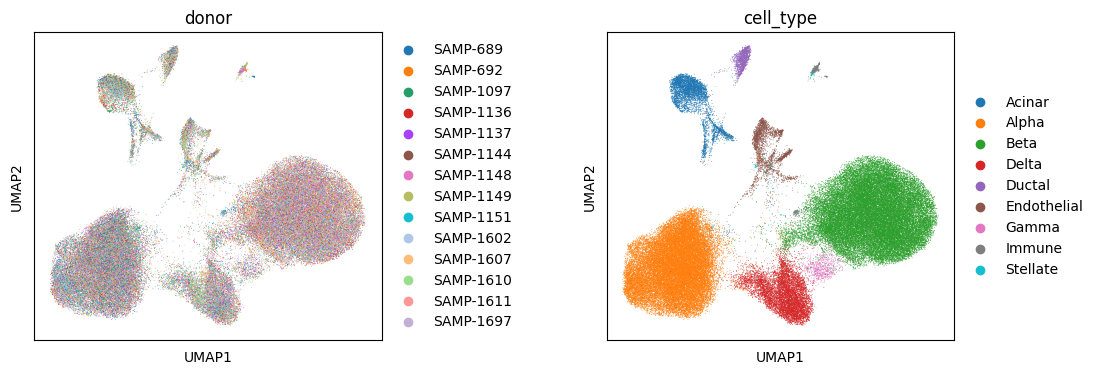

In [74]:
with plt.rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(NG_scATAC_sub,color = ['donor','cell_type'],wspace = 0.5)

In [75]:
NG_scATAC_sub.write_h5ad('scATAC_h5ad/islet_scATAC_NG_final_annotated.h5ad')

In [77]:
NG_scATAC_sub.obs['donor'].value_counts()

donor
SAMP-1697    13373
SAMP-1611     9044
SAMP-1610     7678
SAMP-1149     7663
SAMP-1137     6869
SAMP-1151     6534
SAMP-1602     5689
SAMP-692      5408
SAMP-1097     5259
SAMP-1136     5150
SAMP-1607     4854
SAMP-1144     4656
SAMP-1148     4592
SAMP-689      4217
Name: count, dtype: int64

In [78]:
snap.ex.export_fragments(NG_scATAC_sub,groupby='donor', suffix='.tsv.gz',out_dir = '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/')

{'SAMP-1610': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1610.tsv.gz',
 'SAMP-1149': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1149.tsv.gz',
 'SAMP-1148': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1148.tsv.gz',
 'SAMP-1697': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1697.tsv.gz',
 'SAMP-1611': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1611.tsv.gz',
 'SAMP-692': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-692.tsv.gz',
 'SAMP-1607': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1607.tsv.gz',
 'SAMP-1151': '/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/SAMP-1151.tsv.gz',
 '

In [79]:
NG_scATAC_sub.obs.to_csv('/data/armstrong/islet_public_dataset/human_islet_ATAC_atlas/NG_fragment_high_quality_donor/obs.csv')